In [1]:
import pandas as pd

In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("PS4_GamesSales.csv",encoding="latin-1")
df.head(2)

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09


In [5]:
#Checking how many rows
df.describe

<bound method NDFrame.describe of                                     Game    Year             Genre  \
0                     Grand Theft Auto V  2014.0            Action   
1              Call of Duty: Black Ops 3  2015.0           Shooter   
2                  Red Dead Redemption 2  2018.0  Action-Adventure   
3                     Call of Duty: WWII  2017.0           Shooter   
4                                FIFA 18  2017.0            Sports   
...                                  ...     ...               ...   
1029  Fallen Legion: Flames of Rebellion     NaN      Role-Playing   
1030            Radial G Racing Revolved  2017.0            Racing   
1031                The Mummy Demastered     NaN            Action   
1032          Project Nimbus: Code Mirai     NaN            Action   
1033                 Battle Chef Brigade     NaN            Action   

           Publisher  North America  Europe  Japan  Rest of World  Global  
0     Rockstar Games           6.06    9.71   0.6

In [6]:
print(df.dtypes)

Game                 str
Year             float64
Genre                str
Publisher            str
North America    float64
Europe           float64
Japan            float64
Rest of World    float64
Global           float64
dtype: object


In [7]:
# Check null values
print(df.isnull().sum())

Game               0
Year             209
Genre              0
Publisher        209
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64


In [8]:
df["Year"] = df["Year"].fillna("2012")
print(df.isnull().sum())

Game               0
Year               0
Genre              0
Publisher        209
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64


In [9]:
df["Publisher"] = df["Publisher"].fillna("Unknown")
print(df.isnull().sum())

Game             0
Year             0
Genre            0
Publisher        0
North America    0
Europe           0
Japan            0
Rest of World    0
Global           0
dtype: int64


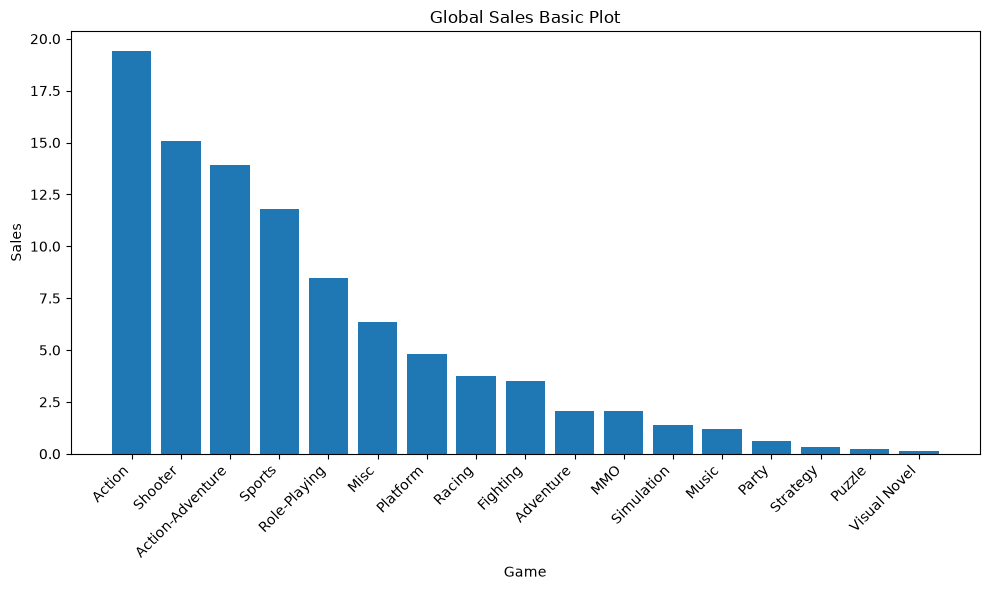

In [10]:
# Basic Bar PLot
plt.figure(figsize=(10,6))
plt.bar(df["Genre"],df["Global"])
plt.title("Global Sales Basic Plot")
plt.xlabel("Game")
plt.ylabel("Sales")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.savefig("Bar_Plot.png")
plt.show()

Year
2013.0     28.76
2014.0    115.85
2015.0    133.99
2016.0    135.72
2017.0    130.90
2018.0     50.20
2019.0      0.00
2020.0      0.00
2012        0.22
Name: Global, dtype: float64


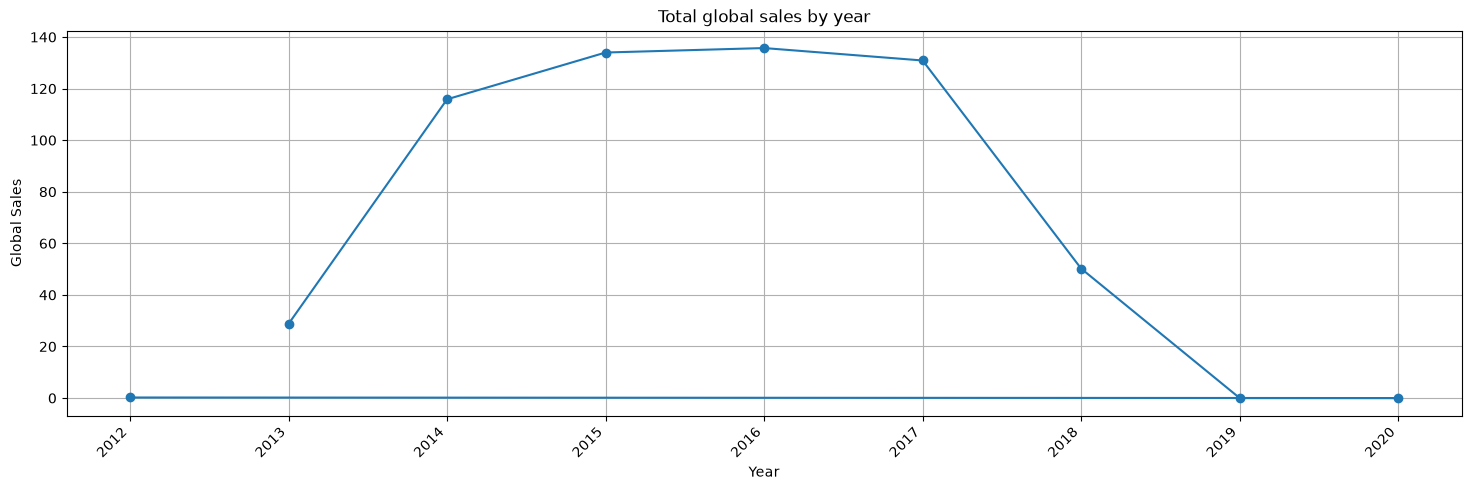

In [14]:
# Basic Line Plot Sales Trend Over Year
sales_by_year = df.groupby("Year")["Global"].sum()
print(sales_by_year)

plt.figure(figsize=(18,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker="o")
plt.title("Total global sales by year")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.grid(True)
plt.xticks(rotation=45,ha="right")
plt.savefig("Line_Plot.png")
plt.show()

Genre
Action              136.85
Action-Adventure     61.86
Adventure            15.22
Fighting             19.46
MMO                   3.52
Misc                 12.47
Music                 5.03
Party                 0.65
Platform             17.85
Puzzle                0.52
Racing               25.29
Role-Playing         62.82
Shooter             134.99
Simulation            4.52
Sports               92.85
Strategy              1.28
Visual Novel          0.46
Name: Global, dtype: float64


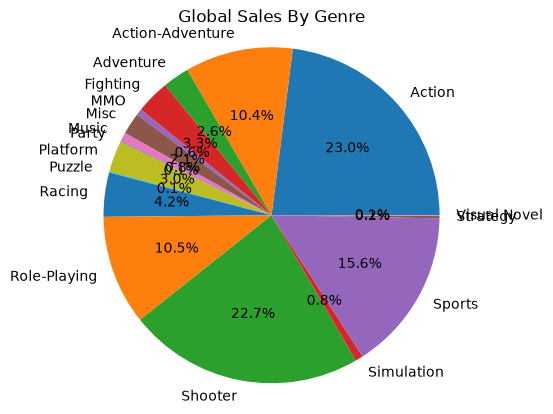

In [12]:
# Basic Pie Chart Sales Genre
genre_sales = df.groupby("Genre")["Global"].sum()
print(genre_sales)

plt.pie(genre_sales,labels=genre_sales.index,autopct="%1.1f%%")
plt.title("Global Sales By Genre")
plt.axis("equal")
plt.show()

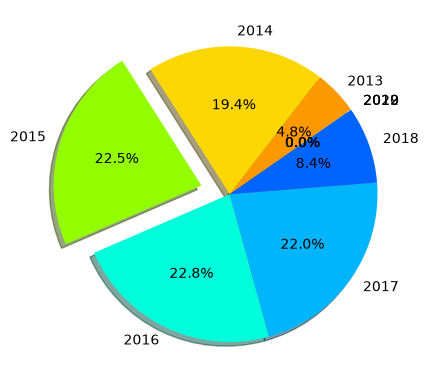

In [16]:
plt.pie(
    sales_by_year,
    labels=sales_by_year.index.astype(int),
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=35,
    shadow=True,
    explode=explode
)

Genre
Action              136.85
Action-Adventure     61.86
Adventure            15.22
Fighting             19.46
MMO                   3.52
Misc                 12.47
Music                 5.03
Party                 0.65
Platform             17.85
Puzzle                0.52
Racing               25.29
Role-Playing         62.82
Shooter             134.99
Simulation            4.52
Sports               92.85
Strategy              1.28
Visual Novel          0.46
Name: Global, dtype: float64


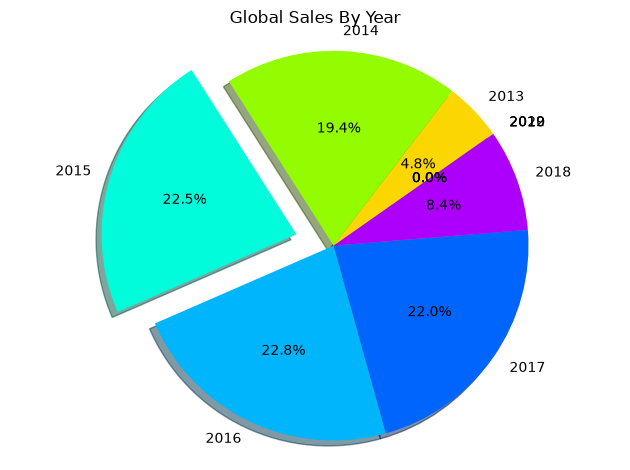

In [17]:
# Basic Pie Chart Sales Genre
df["Year"] = df["Year"].astype(int)

sales_by_year = df.groupby("Year")["Global"].sum()

genre_sales = df.groupby("Genre")["Global"].sum()
print(genre_sales)

explode = [0.2 if year == 2015 else 0 for year in sales_by_year.index]

colors_pie = ["#FC9800","#FCD600","#93FC00","#00FCDA","#00B5FC","#0065FC","#AC00FC","#F2CCBF","#FFDD8A"]
plt.pie(sales_by_year,labels=sales_by_year.index,autopct="%1.1f%%",colors=colors_pie,startangle=35,shadow=True,explode=explode)
plt.title("Global Sales By Year")
plt.axis("equal")
plt.tight_layout()
plt.savefig("Pie_chart.png")
plt.show()